### extracting the values from the par file

In [7]:
# process for a single pulsar parfile.
# need to look at the paper
parfile = r"NANOGrav_9y\par\B1855+09_NANOGrav_9yv1.gls.par"

base_DM = None
epochs = []
dm_values = []
dm_err=[]

with open(parfile) as f:
    for line in f:
        # Remove inline comments
        line = line.split("//")[0].split("#")[0].strip()
        if not line:
            continue

        parts = line.split()
        key = parts[0]
        

        # Base DM
        if key == "DM":
            base_DM = float(parts[1].replace("D", "E"))

        # DMX values and error values
        if key.startswith("DMX_") and not key.startswith("DMXEP"):
            idx = key.split("_")[1]
            dmx = float(parts[1].replace("D", "E"))
            dmxerr = float(parts[3].replace("D", "E")) if len(parts) > 2 else 0.0

            # search for matching epoch
            with open(parfile) as f2:
                for l2 in f2:
                    l2 = l2.split("//")[0].split("#")[0].strip()
                    if l2.startswith(f"DMXEP_{idx}"):
                        epoch = float(l2.split()[1].replace("D", "E"))
                        break

            epochs.append(epoch)
            dm_values.append(dmx)
            dm_err.append(dmxerr)

# Sort results
epochs, dm_values, dm_err = zip(*sorted(zip(epochs, dm_values, dm_err)))

for e, d, err in zip(epochs, dm_values, dm_err):
    print(f"MJD {e} -> DMX {d} ± {err}")

MJD 53358.72746 -> DMX 0.015161863 ± 0.00351684846
MJD 53420.54893 -> DMX 0.0152370685 ± 0.00351683449
MJD 53448.4737 -> DMX 0.0151895956 ± 0.00351649738
MJD 53477.39628 -> DMX 0.0151322502 ± 0.00351653508
MJD 53532.23281 -> DMX 0.0151076504 ± 0.00351662711
MJD 53603.03632 -> DMX 0.015263814 ± 0.00351647013
MJD 53628.96526 -> DMX 0.0151897641 ± 0.003516599
MJD 53686.79761 -> DMX 0.0152890326 ± 0.00351651389
MJD 53715.73064 -> DMX 0.0152484643 ± 0.0035165631
MJD 53750.62273 -> DMX 0.0153422398 ± 0.00351652136
MJD 53798.50108 -> DMX 0.015354092 ± 0.00351660466
MJD 53851.37182 -> DMX 0.0154295455 ± 0.0035165139
MJD 53891.24728 -> DMX 0.0154693407 ± 0.00351653286
MJD 53926.16326 -> DMX 0.0156001615 ± 0.00351689266
MJD 53968.05725 -> DMX 0.0157477908 ± 0.00351642748
MJD 54008.95372 -> DMX 0.0159397058 ± 0.0035163291
MJD 54043.83682 -> DMX 0.0159157339 ± 0.00351644531
MJD 54092.71265 -> DMX 0.016023921 ± 0.00351654202
MJD 54135.58282 -> DMX 0.0161119039 ± 0.00351660022
MJD 54177.47297 -> DMX

## plotted according to NANOGrav description of these plots

### plotting as is

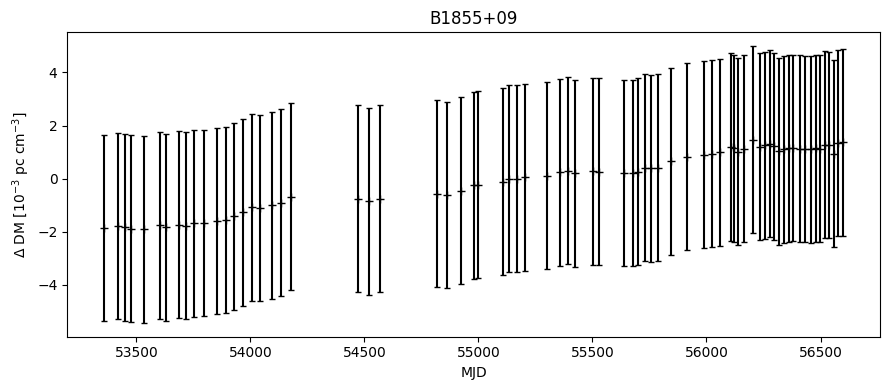

In [39]:
import numpy as np
import matplotlib.pyplot as plt

t = np.array(epochs)
dm = np.array(dm_values)
dm_err = np.array(dm_err)

# fiducial DM (zero point)
DM0 = np.mean(dm)

# ΔDM and errors
dDM = dm - DM0
dDM_err = dm_err

# plot
plt.figure(figsize=(9,4))
plt.errorbar(
    t,
    dDM * 1e3,
    yerr=dDM_err *1e3 ,
    fmt='+',
    color='k',
    capsize=2
)

plt.xlabel("MJD")
plt.ylabel(r"$\Delta$ DM [$10^{-3}$ pc cm$^{-3}$]")
plt.title("B1855+09")
plt.tight_layout()
plt.show()


In [40]:
dDM_err*1e3

array([3.51684846, 3.51683449, 3.51649738, 3.51653508, 3.51662711,
       3.51647013, 3.516599  , 3.51651389, 3.5165631 , 3.51652136,
       3.51660466, 3.5165139 , 3.51653286, 3.51689266, 3.51642748,
       3.5163291 , 3.51644531, 3.51654202, 3.51660022, 3.51653637,
       3.51647068, 3.51654829, 3.51655413, 3.51660433, 3.51663094,
       3.51659233, 3.51680449, 3.51700298, 3.51669195, 3.51673492,
       3.5168257 , 3.5166332 , 3.51779101, 3.5171169 , 3.51729708,
       3.51711273, 3.51670777, 3.51683726, 3.51654536, 3.51659552,
       3.51685651, 3.51754173, 3.51701302, 3.51698583, 3.51656249,
       3.5165082 , 3.51641019, 3.51643393, 3.51830253, 3.52479233,
       3.52162978, 3.5266043 , 3.52069768, 3.51633835, 3.51594287,
       3.51620206, 3.51757322, 3.51582953, 3.51721613, 3.51582826,
       3.51580352, 3.51571012, 3.51612171, 3.51601523, 3.51651911,
       3.51659645, 3.51643552, 3.51645118, 3.51609445, 3.52468823,
       3.51656154, 3.515863  ])

In [41]:
dDM*1e3

array([-1.85798525e+00, -1.78277975e+00, -1.83025265e+00, -1.88759805e+00,
       -1.91219785e+00, -1.75603425e+00, -1.83008415e+00, -1.73081565e+00,
       -1.77138395e+00, -1.67760845e+00, -1.66575625e+00, -1.59030275e+00,
       -1.55050755e+00, -1.41968675e+00, -1.27205745e+00, -1.08014245e+00,
       -1.10411435e+00, -9.95927246e-01, -9.07944346e-01, -6.81649946e-01,
       -7.50247046e-01, -8.57128646e-01, -7.57728546e-01, -5.71445646e-01,
       -6.09377146e-01, -4.50812246e-01, -2.51858846e-01, -2.22109046e-01,
       -1.17702846e-01,  6.97485417e-03, -4.75545833e-04,  5.40307542e-02,
        1.11665454e-01,  2.46665854e-01,  2.99020454e-01,  1.97908554e-01,
        2.72819654e-01,  2.62053154e-01,  2.11108054e-01,  2.14475854e-01,
        2.64777654e-01,  4.09685054e-01,  3.93691554e-01,  4.21260154e-01,
        6.51825554e-01,  8.25922054e-01,  9.03664654e-01,  9.35308654e-01,
        1.00160755e+00,  1.19485585e+00,  1.14039245e+00,  1.02321035e+00,
        1.13295035e+00,  

errs are larger then the values themselves??

In [60]:
import numpy as np
from scipy.optimize import curve_fit

t = np.array(epochs)
dm = np.array(dm_values)
sigma = np.array(dm_err)
# assumption - dm_err are the 1σ TEMPO uncertainties.
def dm_model(t, c0, c1, c2, c3, c4):
    return c0*np.cos(c1*t + c2) + c3*t + c4

# reasonable initial guesses
# amplitude ~ half peak-to-peak
c0_0 = 0.5 * (dm.max() - dm.min())

# period ~ data span (one oscillation)
T0 = t.max() - t.min()
c1_0 = 2 * np.pi / T0

# phase
c2_0 = 0.0

# linear trend ~ 0
c3_0 = 0.0

# offset ~ mean DM
c4_0 = dm.mean()

p0 = [c0_0, c1_0, c2_0, c3_0, c4_0]


popt, pcov = curve_fit(
    dm_model,
    t,
    dm,
    p0=p0,
    sigma=sigma,
    absolute_sigma=True,
    maxfev=20000
)


c0, c1, c2, c3, c4 = popt
print("Fitted parameters:")
print(f"c0 = {c0}, c1 = {c1}, c2 = {c2}, c3 = {c3}, c4 = {c4}")

Fitted parameters:
c0 = 0.15495266474592975, c1 = 0.00010657122123672448, c2 = 99.40700694961923, c3 = -1.54079859524087e-05, c4 = 0.8603490124672759


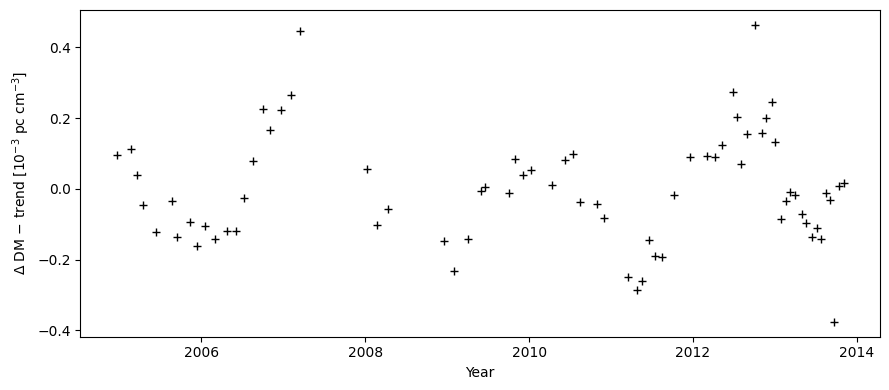

In [61]:
# MJD -> year
year = 2000.0 + (t - 51544.5) / 365.25

# fiducial DM
DM0 = np.mean(dm)

# ΔDM
dDM = dm - DM0

# trend and residuals
dm_trend = dm_model(t, c0, c1, c2, c3, c4)
dDM_trend = dm_trend - DM0
residuals = dDM - dDM_trend

# plot
plt.figure(figsize=(9,4))
plt.errorbar(
    year,
    residuals*1e3 ,
    # yerr=dm_err *1e3 ,
    fmt='+',
    color='k',
    capsize=2
)

plt.xlabel("Year")
plt.ylabel(r"$\Delta$ DM $-$ trend [$10^{-3}$ pc cm$^{-3}$]")
# plt.text(0.05, 0.85, r"$\chi_r^2 = 16$", transform=plt.gca().transAxes)

plt.tight_layout()
plt.show()

## Structure function plot

In [9]:
# making the time series.
# first subtract the 0th mjd DM, then you get time in the scale of mjd, and then self-corelate the new subtracted DM time series.
start_epoch = epochs[0]
time=np.array(epochs) - start_epoch
Ddm=np.array(dm_values)-dm_values[0]
def autocorr_at_lags(times, values, nlags=30):
    times = np.array(times)
    values = np.array(values)
    max_lag = times[-1] - times[0]
    lags = np.logspace(0.1, np.log10(max_lag), nlags)
    
    acf = []
    for lag in lags:
        diffs = []
        for i in range(len(times)):
            for j in range(i+1, len(times)):
                if abs((times[j] - times[i]) - lag) < 0.1*lag:
                    diffs.append(values[i] * values[j])
        acf.append(np.mean(diffs) if diffs else np.nan)
    
    return lags, np.array(acf)
lags, acf = autocorr_at_lags(time, Ddm, nlags=30)

In [12]:
import numpy as np

def compute_structure_function(times, dm_values, nbins=30):
    times = np.array(times)
    dm_values = np.array(dm_values)

    max_lag = times[-1] - times[0]
    lags = np.logspace(0.1, np.log10(max_lag), nbins)
    
    sf, sf_err = [], []
    for tau in lags:
        diffs = []
        for i in range(len(times)):
            for j in range(i+1, len(times)):
                dt = abs(times[j] - times[i])
                if (0.9*tau <= dt <= 1.1*tau):
                    diffs.append((dm_values[j] - dm_values[i])**2)
        if diffs:
            diffs = np.array(diffs)
            sf.append(np.mean(diffs))
            sf_err.append(np.std(diffs)/np.sqrt(len(diffs)))  # standard error
        else:
            sf.append(np.nan)
            sf_err.append(np.nan)

    return lags, np.array(sf), np.array(sf_err)
lags, sf, sf_err = compute_structure_function(time, Ddm)

Anchored SF fit (paper-consistent)
  beta    = 4.006 ± 0.016
  C_noise = 2.052e-08


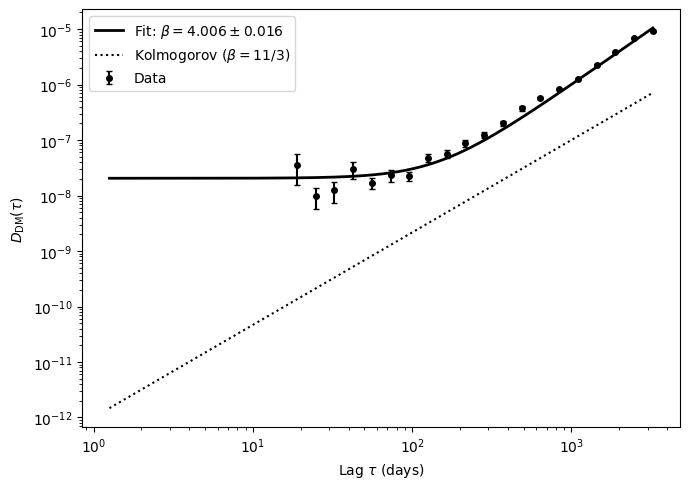

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ============================================================
# 1. Paper constants (Eq. 10)
# ============================================================
nu_GHz = 1.5                              # observing frequency
A_nu = 3.84e-5 * nu_GHz**(-2)             # paper normalization
A_fixed = A_nu**2                         # (A_ν)^2

# ============================================================
# 2. Pulsar-specific diffractive timescale (days)
#    THIS MUST come from the paper or scintillation analysis
# ============================================================
tau_D = 30.0   # <-- replace with correct value for your pulsar

# ============================================================
# 3. Structure function model (anchored)
# ============================================================
def SF_DM(tau, beta, f_scale, C_noise):
    return f_scale * A_fixed * (tau / tau_D)**(beta - 2) + C_noise


# ============================================================
# 4. Prepare data
# ============================================================
valid = np.isfinite(sf) & (sf > 0)
lags_v = lags[valid]
sf_v = sf[valid]
err_v = sf_err[valid]

# ------------------------------------------------------------
# Remove noise-dominated / upper-limit region
# Paper fits ONLY tau > tau_D
# ------------------------------------------------------------
mask = lags_v > tau_D
tau_fit = lags_v[mask]
sf_fit = sf_v[mask]
err_fit = err_v[mask]

if len(tau_fit) < 3:
    raise RuntimeError("Not enough points above tau_D to fit.")

# ============================================================
# 5. Fit beta and noise
# ============================================================
p0 = [3.7, 1.0, np.min(sf_fit)]
bounds = (
    [3.0, 0.3, 0.0],   # beta, scale, noise
    [4.2, 3.0, np.inf]
)

popt, pcov = curve_fit(
    SF_DM,
    tau_fit,
    sf_fit,
    sigma=err_fit,
    absolute_sigma=True,
    p0=p0,
    bounds=bounds,
    maxfev=30000
)

beta, f_scale, C_noise = popt
perr = np.sqrt(np.diag(pcov))
print("Anchored SF fit (paper-consistent)")
print(f"  beta    = {beta:.3f} ± {perr[0]:.3f}")
print(f"  C_noise = {C_noise:.3e}")

# ============================================================
# 6. Plot (matches Fig. 13 style)
# ============================================================
plt.figure(figsize=(7, 5))

plt.errorbar(
    lags, sf, yerr=sf_err,
    fmt='o', color='k', ms=4, capsize=2, label='Data'
)

tau_plot = np.logspace(np.log10(lags.min()), np.log10(lags.max()), 300)

plt.plot(
    tau_plot,
    SF_DM(tau_plot, beta, f_scale, C_noise),
    'k-', lw=2,
    label=rf'Fit: $\beta={beta:.3f}\pm{perr[0]:.3f}$'
)


# Optional: Kolmogorov reference line
beta_kolm = 11/3
plt.plot(
    tau_plot,
    A_fixed * (tau_plot / tau_D)**(beta_kolm - 2),
    'k:', lw=1.5, label=r'Kolmogorov ($\beta=11/3$)'
)

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'Lag $\tau$ (days)')
plt.ylabel(r'$D_{\rm DM}(\tau)$')
plt.legend()
plt.tight_layout()
plt.show()
